In [ ]:
import ast
import math
from collections import Counter
from igraph import Graph
from itertools import combinations
from collections import Counter
import os


#############################################################
# RARITY OF A RULE
#############################################################

# def rarity_rule(rule, global_frequency):

#     rarity = 0

#     for pair in rule:

#         rarity += global_frequency[pair]

#     return 1- (rarity / len(rule))

#############################################################
# GLOBAL ATTRIBUTE-VALUE FREQUENCY
#############################################################

def compute_global_frequency(rules):

    counter = Counter()

    total_pairs = 0

    for rule in rules:

        for pair in rule:

            counter[pair] += 1
            total_pairs += 1

    freq = {}

    for pair, count in counter.items():

        freq[pair] = count / total_pairs

    return freq, total_pairs

#############################################################
# REUSE OF A RULE
#############################################################

def reuse_rule(rule, community_id, community_frequency):

    reuse = 0

    freq = community_frequency[community_id]

    for pair in rule:
        if freq[pair] == 1 / len(community_frequency):
            reuse += 1
        else:
            reuse += 1 - freq[pair]

    return reuse / len(rule)

#############################################################
# COMMUNITY ATTRIBUTE-VALUE FREQUENCY
#############################################################

from collections import defaultdict

def compute_community_frequency(rules, membership):

    community_rules = defaultdict(list)

    # Agrupar reglas por comunidad
    for idx, comm in enumerate(membership):

        community_rules[comm].append(idx)

    community_frequency = {}

    for comm, rule_ids in community_rules.items():

        counter = Counter()

        n_rules = len(rule_ids)

        for rid in rule_ids:

            # Para evitar contar dos veces el mismo atributo si aparece repetido
            for pair in set(rules[rid]):

                counter[pair] += 1

        freq = {}

        for pair, count in counter.items():

            freq[pair] = count / n_rules

        community_frequency[comm] = freq

    return community_frequency

def jaccard_similarity(rule1, rule2):

    s1 = set(rule1)
    s2 = set(rule2)

    inter = len(s1.intersection(s2))
    union = len(s1.union(s2))

    if union == 0:
        return 0

    return inter / union

#############################################################
# NKC METRIC
#############################################################

def compute_NKC(rules,membership,alpha=1):

    global_frequency, total_pairs = compute_global_frequency(rules)

    community_frequency = compute_community_frequency(rules, membership)

    nkc = 0
    nkc_reuse = 0
    nkc_rarity = 0

    details = []

    for idx, rule in enumerate(rules):

        size = len(rule)

        rarity = rarity_rule(rule,global_frequency, total_pairs)

        reuse = reuse_rule(rule, membership[idx], community_frequency)

        if reuse == 1 / len(rule):
            reuse = 0

        reuse = 1 - reuse
            
        score = (
            size ** alpha
        ) *  (
            (rarity + reuse) / 2
        )

        nkc += score
        nkc_reuse += ( size ** alpha ) * ( reuse )
        nkc_rarity += ( size ** alpha ) * ( rarity )

        details.append({

            "rule": idx,

            "community": membership[idx],

            "size": size,

            "rarity": rarity,

            "reuse": reuse,

            "complexity": score

        })

    return nkc, details, nkc_reuse, nkc_rarity

#############################################################
# COMMUNITY DETECTION
#############################################################

def detect_communities(graph):

    communities = graph.community_multilevel(
        weights=graph.es["weight"]
    )

    graph.vs["community"] = communities.membership

    return communities

#############################################################
# RULE GRAPH
#############################################################

def build_rule_graph(rules, threshold=0.5):

    g = Graph()

    g.add_vertices(len(rules))

    edges = []
    weights = []

    for i, j in combinations(range(len(rules)), 2):

        sim = jaccard_similarity(
            rules[i],
            rules[j]
        )

        if sim >= threshold:

            edges.append((i, j))
            weights.append(sim)

    g.add_edges(edges)

    g.es["weight"] = weights

    return g

def load_rules(file_name):

    rules = []

    with open(file_name, "r") as f:

        for line in f:

            line = line.strip()

            if line == "":
                continue

            rule = ast.literal_eval(line)

            attrs = []

            for att in rule[1]:

                attrs.append(
                    (att[0], str(att[1]))
                )

            rules.append(attrs)

    return rules


#############################################################
# WSC
#############################################################

def compute_wsc(rules):

    return sum(len(rule) for rule in rules)


#############################################################
# GLOBAL FREQUENCIES
#############################################################

def compute_global_frequencies(rules):

    counter = Counter()

    total_pairs = 0

    for rule in rules:

        for pair in rule:

            counter[pair] += 1
            total_pairs += 1

    frequencies = {}

    for pair, count in counter.items():

        frequencies[pair] = count / total_pairs

    return frequencies

#############################################################
# COMMUNITY REUSE FACTOR
#############################################################

def compute_reuse_factor(rules, membership):

    reuse = {}

    n_communities = max(membership) + 1

    for cid in range(n_communities):

        unique_pairs = set()

        total_pairs = 0

        for idx, rule in enumerate(rules):

            if membership[idx] != cid:
                continue

            total_pairs += len(rule)

            for pair in rule:
                unique_pairs.add(pair)

        if total_pairs == 0:

            reuse[cid] = 1.0

        else:

            reuse[cid] = len(unique_pairs) / total_pairs

    return reuse

#############################################################
# SHANNON RARITY
#############################################################

def rarity_rule(rule, frequencies, policy_len):

    rarity = 0

    for pair in rule:
        if frequencies[pair] == 1 / policy_len:
            rarity += 1
        else:
            rarity += (1 - frequencies[pair])
        
    return rarity / len(rule)


#############################################################
# NEW METRIC
#############################################################



#############################################################
# PRINT COMPARISON
#############################################################

def compare_metrics(file_name, edge_th, alpha_):

    rules = load_rules(file_name)
    results = []

    ####################################################
    # RULE GRAPH
    ####################################################

    graph = build_rule_graph(
        rules,
        threshold=edge_th
    )

    ####################################################
    # COMMUNITY DETECTION
    ####################################################

    communities = detect_communities(graph)
    print("\nRule Graph")
    print("Nodes:", graph.vcount())
    print("Edges:", graph.ecount())
    print("Density:", round(graph.density(),4))

    print("Communities:", len(communities))

    sizes = [len(c) for c in communities]

    print("Community sizes:", sizes)

    wsc = compute_wsc(rules)

    nkc, details, nkc_reuse, nkc_rarity = compute_NKC(
        rules,
        communities.membership,
        alpha=alpha_
    )


    print("="*70)

    print("Rule | Comm | Size | Rareza | Reuso | NKC")

    print("="*70)

    for d in details:

        print(

            f"{d['rule']:3d} | "

            f"{d['community']:3d} | "

            f"{d['size']:2d} | "

            f"{d['rarity']:.3f} | "

            f"{d['reuse']:.3f} | "

            f"{d['complexity']:.3f}"

    )
    
    print("=" * 60)

    print("Policy")

    print("=" * 60)

    print("Rules:", len(rules))

    print("WSC:", round(wsc, 2))
    
    print(f"NKC(G_R): {nkc:.4f}")
    print(f"NKC(G_R)-Rarity: {nkc_rarity:.4f}")
    print(f"NKC(G_R)-Reuse: {nkc_reuse:.4f}")

    #Comparing
    
    comparing = (wsc-nkc) / wsc
    

    print(f"DIFF: {comparing:.4f}")

    return {
        "policy": os.path.basename(file_name),
        "rules": len(rules),
        "wsc": wsc,
        "nkc": nkc,
        "nkc_ratio": nkc / wsc,
        "nkc_rarity": nkc_rarity,
        "nkc_reuse": nkc_reuse,
        "communities": len(communities),
        "density": graph.density(),
        "nodes": graph.vcount(),
        "edges": graph.ecount(),
        "diff": comparing
    }

    #compare_metrics("/home/daniel/Documents/phd/phd-thesis-lab/17_NuevoAnalisisP1/reglas_abac.txt")

In [157]:
compare_metrics("00_policies/WSC40-R14-MED.txt", 0.1, 1)


Rule Graph
Nodes: 14
Edges: 26
Density: 0.2857
Communities: 3
Community sizes: [4, 5, 5]
Rule | Comm | Size | Rareza | Reuso | NKC
  0 |   0 |  3 | 0.968 | 0.500 | 2.202
  1 |   0 |  3 | 0.968 | 0.500 | 2.202
  2 |   0 |  3 | 0.968 | 0.500 | 2.202
  3 |   0 |  3 | 0.968 | 0.500 | 2.202
  4 |   1 |  3 | 0.960 | 0.467 | 2.140
  5 |   1 |  3 | 0.960 | 0.467 | 2.140
  6 |   1 |  3 | 0.960 | 0.467 | 2.140
  7 |   1 |  3 | 0.960 | 0.467 | 2.140
  8 |   1 |  3 | 0.960 | 0.467 | 2.140
  9 |   2 |  3 | 0.960 | 0.467 | 2.140
 10 |   2 |  3 | 0.960 | 0.467 | 2.140
 11 |   2 |  3 | 0.960 | 0.467 | 2.140
 12 |   2 |  3 | 0.960 | 0.467 | 2.140
 13 |   2 |  3 | 0.960 | 0.467 | 2.140
Policy
Rules: 14
WSC: 42
NKC(G_R): 30.2143
NKC(G_R)-Rarity: 40.4286
NKC(G_R)-Reuse: 20.0000
DIFF: 0.2806


{'policy': 'WSC40-R14-MED.txt',
 'rules': 14,
 'wsc': 42,
 'nkc': 30.214285714285708,
 'nkc_rarity': 40.428571428571416,
 'nkc_reuse': 20.0,
 'communities': 3,
 'density': 0.2857142857142857,
 'nodes': 14,
 'edges': 26,
 'diff': 0.28061224489795933}

In [169]:
import os

def compare_all_policies(folder, edge_th=0.25, alpha=1):

    results = []
    edge_thr = [ 0.25, 0.25, 0.25, 0.1, 0.5, 0.1, 0.1, 0.5, 0.1, 0.1, 0.2, 0.1,
                0.05, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1,
                0.1, 0.1]
    id_edge = 0

    for file in sorted(os.listdir(folder)):

        if not file.endswith(".txt"):
            continue

        result = compare_metrics(
            os.path.join(folder, file),
            edge_thr[id_edge],
            alpha
        )
        id_edge += 1

        results.append(result)

    return results

results = compare_all_policies(
    "00_policies",
    edge_th=0.25,
    alpha=1.5
)


Rule Graph
Nodes: 10
Edges: 45
Density: 1.0
Communities: 1
Community sizes: [10]
Rule | Comm | Size | Rareza | Reuso | NKC
  0 |   0 |  2 | 0.750 | 0.050 | 1.131
  1 |   0 |  2 | 0.750 | 0.050 | 1.131
  2 |   0 |  2 | 0.750 | 0.050 | 1.131
  3 |   0 |  2 | 0.750 | 0.050 | 1.131
  4 |   0 |  2 | 0.750 | 0.050 | 1.131
  5 |   0 |  2 | 0.750 | 0.050 | 1.131
  6 |   0 |  2 | 0.750 | 0.050 | 1.131
  7 |   0 |  2 | 0.750 | 0.050 | 1.131
  8 |   0 |  2 | 0.750 | 0.050 | 1.131
  9 |   0 |  2 | 0.750 | 0.050 | 1.131
Policy
Rules: 10
WSC: 20
NKC(G_R): 11.3137
NKC(G_R)-Rarity: 21.2132
NKC(G_R)-Reuse: 1.4142
DIFF: 0.4343

Rule Graph
Nodes: 10
Edges: 0
Density: 0.0
Communities: 10
Community sizes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Rule | Comm | Size | Rareza | Reuso | NKC
  0 |   0 |  2 | 1.000 | 1.000 | 2.828
  1 |   1 |  2 | 1.000 | 1.000 | 2.828
  2 |   2 |  2 | 1.000 | 1.000 | 2.828
  3 |   3 |  2 | 1.000 | 1.000 | 2.828
  4 |   4 |  2 | 1.000 | 1.000 | 2.828
  5 |   5 |  2 | 1.000 | 1.000 | 2.82

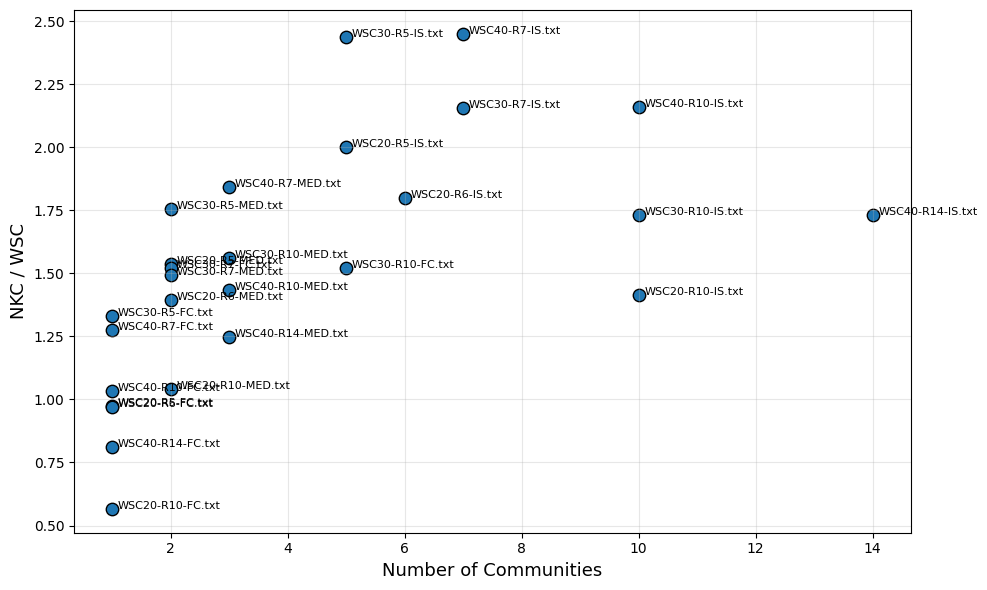

In [171]:
import matplotlib.pyplot as plt

def plot_nkc_ratio_vs_communities(results):

    x = [r["communities"] for r in results]
    y = [r["nkc"] / r["wsc"] for r in results]
    labels = [r["policy"] for r in results]

    plt.figure(figsize=(10,6))

    plt.scatter(
        x,
        y,
        s=80,
        edgecolor="black"
    )

    for xi, yi, label in zip(x, y, labels):
        plt.text(
            xi + 0.1,
            yi,
            label,
            fontsize=8
        )

    plt.xlabel("Number of Communities", fontsize=13)
    plt.ylabel("NKC / WSC", fontsize=13)
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_nkc_ratio_vs_communities(results)


/tmp/ipykernel_22092/669244339.py:105: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


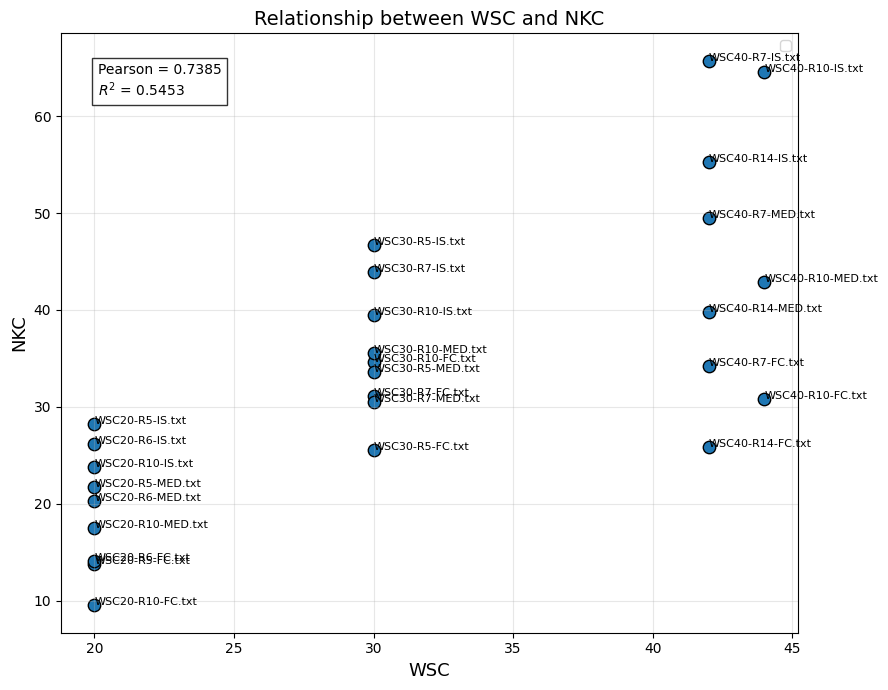

Correlation Analysis
Pearson  : 0.73846 (p=1.0938e-05)
Spearman : 0.75733 (p=4.8031e-06)
R²       : 0.54533


In [167]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression


def plot_wsc_vs_nkc(results):

    ######################################################
    # DATA
    ######################################################

    wsc = np.array([r["wsc"] for r in results])

    nkc = np.array([r["nkc"] for r in results])

    labels = [r["policy"] for r in results]

    ######################################################
    # LINEAR REGRESSION
    ######################################################

    model = LinearRegression()

    model.fit(
        wsc.reshape(-1,1),
        nkc
    )

    predicted = model.predict(
        wsc.reshape(-1,1)
    )

    r2 = model.score(
        wsc.reshape(-1,1),
        nkc
    )

    ######################################################
    # CORRELATIONS
    ######################################################

    pearson, p1 = pearsonr(wsc, nkc)

    spearman, p2 = spearmanr(wsc, nkc)

    ######################################################
    # PLOT
    ######################################################

    plt.figure(figsize=(9,7))

    plt.scatter(
        wsc,
        nkc,
        s=80,
        edgecolor="black"
    )
    ######################################################
    # Labels
    ######################################################

    for x, y, label in zip(wsc, nkc, labels):

        plt.text(
            x,
            y,
            label,
            fontsize=8
        )

    ######################################################
    # Statistics
    ######################################################

    txt = (
        f"Pearson = {pearson:.4f}\n"
        f"$R^2$ = {r2:.4f}"
    )

    plt.text(
        0.05,
        0.95,
        txt,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(
            facecolor="white",
            alpha=0.8
        )
    )

    ######################################################

    plt.xlabel("WSC", fontsize=13)

    plt.ylabel("NKC", fontsize=13)

    plt.title("Relationship between WSC and NKC", fontsize=14)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

    ######################################################
    # PRINT
    ######################################################

    print("="*60)

    print("Correlation Analysis")

    print("="*60)

    print(f"Pearson  : {pearson:.5f} (p={p1:.4e})")

    print(f"Spearman : {spearman:.5f} (p={p2:.4e})")

    print(f"R²       : {r2:.5f}")

plot_wsc_vs_nkc(results)

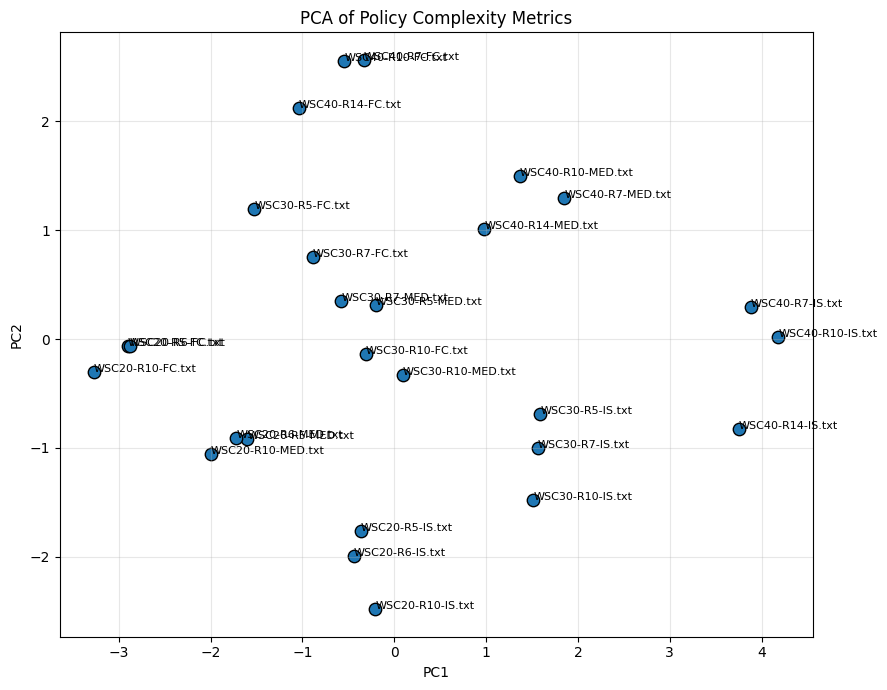

PCA Loadings
WSC             PC1=  0.350 PC2=  0.545
NKC             PC1=  0.502 PC2=  0.105
Rareza          PC1=  0.380 PC2=  0.501
Reuso           PC1=  0.460 PC2= -0.251
Density         PC1= -0.357 PC2=  0.455
Communities     PC1=  0.377 PC2= -0.414

Explained variance
[0.63262612 0.28078709]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def plot_policy_pca(results):

    ##########################################################
    # MATRIX
    ##########################################################

    X = np.array([

        [

            r["wsc"],

            r["nkc"],

            r["nkc_rarity"],

            r["nkc_reuse"],

            r["density"],

            r["communities"]

        ]

        for r in results

    ])

    ##########################################################
    # STANDARDIZATION
    ##########################################################

    scaler = StandardScaler()

    X = scaler.fit_transform(X)

    ##########################################################
    # PCA
    ##########################################################

    pca = PCA(n_components=2)

    Xp = pca.fit_transform(X)

    ##########################################################
    # PLOT
    ##########################################################

    plt.figure(figsize=(9,7))

    plt.scatter(

        Xp[:,0],

        Xp[:,1],

        s=80,

        edgecolor="black"

    )

    ##########################################################
    # LABELS
    ##########################################################

    for point, r in zip(Xp, results):

        plt.text(

            point[0],

            point[1],

            r["policy"],

            fontsize=8

        )

    ##########################################################

    plt.xlabel(

        f"PC1"

    )

    plt.ylabel(

        f"PC2"

    )

    plt.title(

        "PCA of Policy Complexity Metrics"

    )

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    ##########################################################
    # PRINT LOADINGS
    ##########################################################

    variables = [

        "WSC",

        "NKC",

        "Rareza",

        "Reuso",

        "Density",

        "Communities"

    ]

    print("="*60)

    print("PCA Loadings")

    print("="*60)

    for var, loading in zip(variables, pca.components_.T):

        print(

            f"{var:15s} "

            f"PC1={loading[0]:7.3f} "

            f"PC2={loading[1]:7.3f}"

        )

    print()

    print("Explained variance")

    print(pca.explained_variance_ratio_)

plot_policy_pca(results)